In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

<h3>Data Cleaning and Preperation</h3>

In [2]:
# Load the dataframe.
df_copy = pd.read_csv('heart_disease.csv')
df = df_copy.copy()

# Drop the 'Heart Disease Status' column as it is the target variable.
#df_processed = df.drop(columns=['Heart Disease Status', 'Alcohol Consumption'])
df_processed = df.drop(columns=['Heart Disease Status'])
print(df_processed)

       Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0     56.0    Male           153.0              155.0            High     Yes   
1     69.0  Female           146.0              286.0            High      No   
2     46.0    Male           126.0              216.0             Low      No   
3     32.0  Female           122.0              293.0            High     Yes   
4     60.0    Male           166.0              242.0             Low     Yes   
...    ...     ...             ...                ...             ...     ...   
9995  25.0  Female           136.0              243.0          Medium     Yes   
9996  38.0    Male           172.0              154.0          Medium      No   
9997  73.0    Male           152.0              201.0            High     Yes   
9998  23.0    Male           142.0              299.0             Low     Yes   
9999  38.0  Female           128.0              193.0          Medium     Yes   

     Family Heart Disease D

In [ ]:
# Impute missing values for numerical columns using the mean.
for col in df_processed.select_dtypes(include=['float64']).columns:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mean())

# Impute missing values for categorical columns using the mode.
for col in df_processed.select_dtypes(include=['object']).columns:
    df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

# Map binary and ordinal categorical columns to numerical values.
mapping = {
    'Gender': {'Male': 1, 'Female': 0},
    'Smoking': {'Yes': 1, 'No': 0},
    'Family Heart Disease': {'Yes': 1, 'No': 0},
    'Diabetes': {'Yes': 1, 'No': 0},
    'High Blood Pressure': {'Yes': 1, 'No': 0},
    'Low HDL Cholesterol': {'Yes': 1, 'No': 0},
    'High LDL Cholesterol': {'Yes': 1, 'No': 0},
    'Exercise Habits': {'Low': 0, 'Medium': 1, 'High': 2},
    'Alcohol Consumption': {'None': 0, 'Low': 1, 'Medium': 2, 'High': 3},
    'Stress Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Sugar Consumption': {'Low': 0, 'Medium': 1, 'High': 2},
    'Heart Disease Status': {'Yes': 1, 'No': 0}
}

for col, map_dict in mapping.items():
    df_processed[col] = df_processed[col].map(map_dict)

# Normalize the data.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_processed)

# Apply PCA for dimensionality reduction to 2 components.
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Create a new dataframe with PCA components.
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])

<h3>Elbow Method</h3>

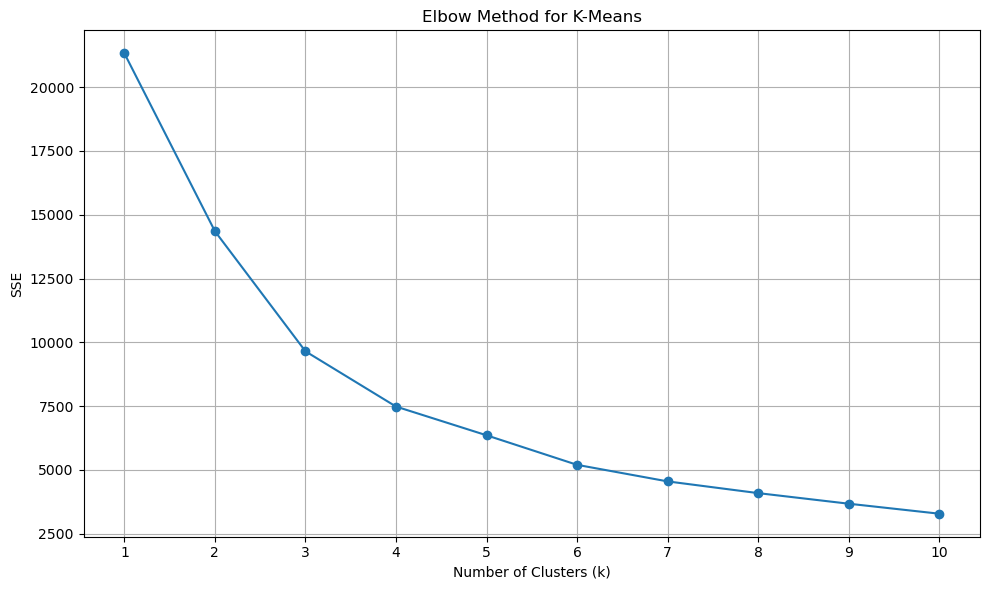

In [4]:
# --- Elbow Method for K-Means ---
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca[['PC1', 'PC2']])
    sse.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE')
plt.grid(True)
plt.xticks(np.arange(1, 11, 1))
plt.tight_layout()
plt.show()

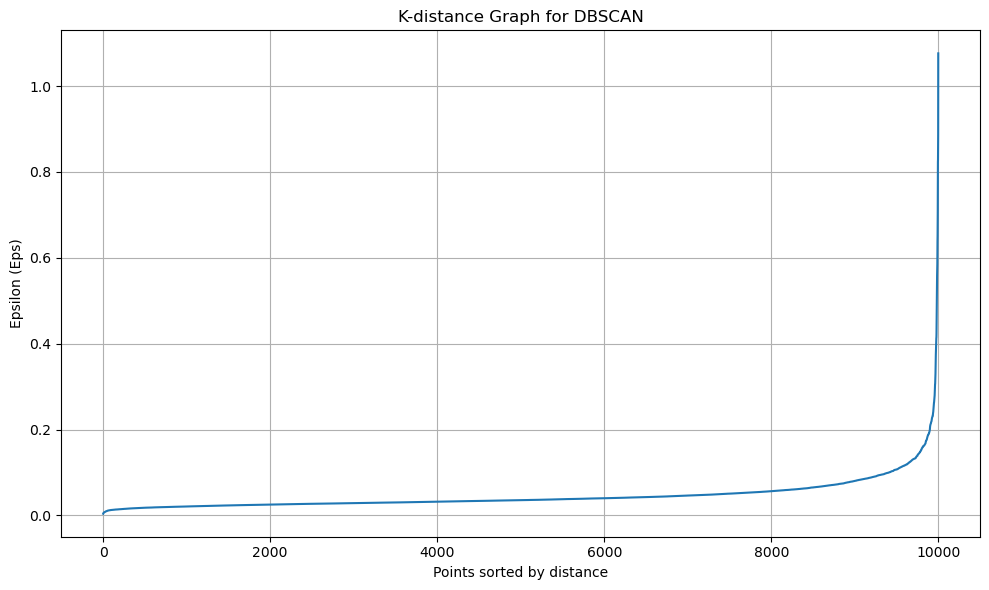

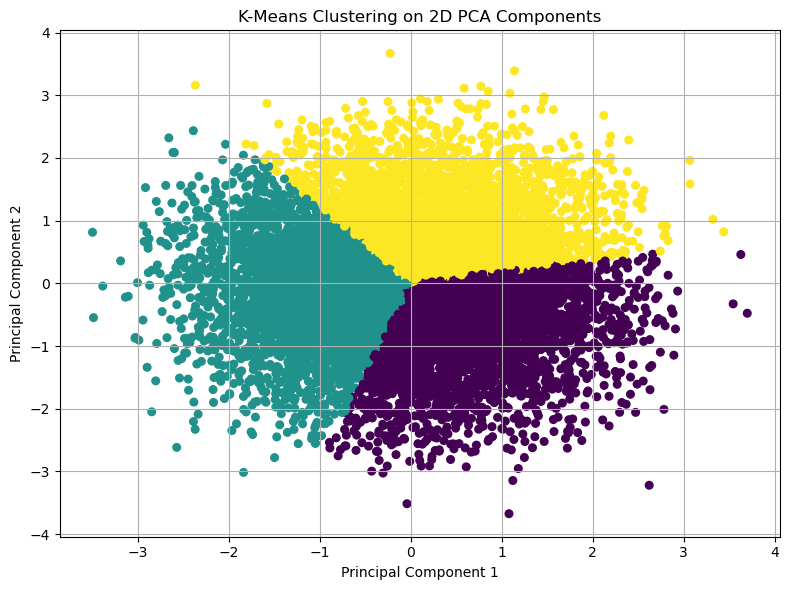

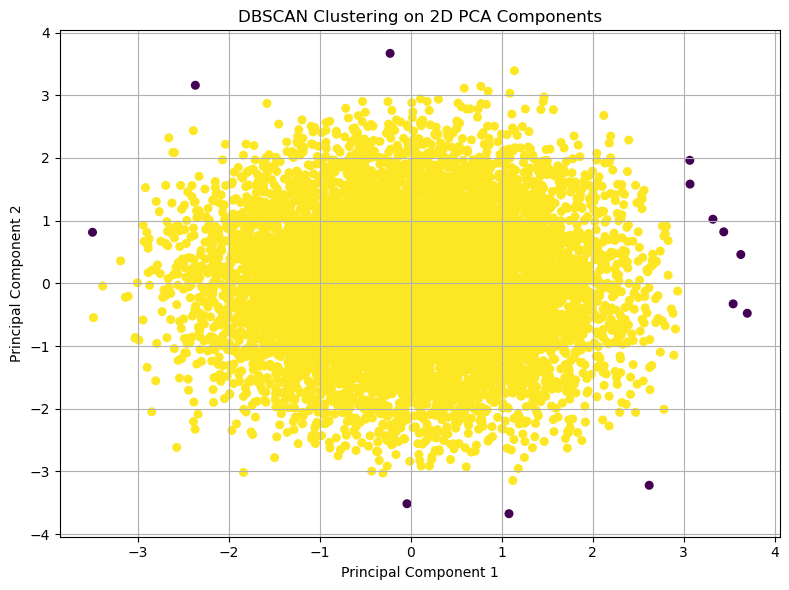

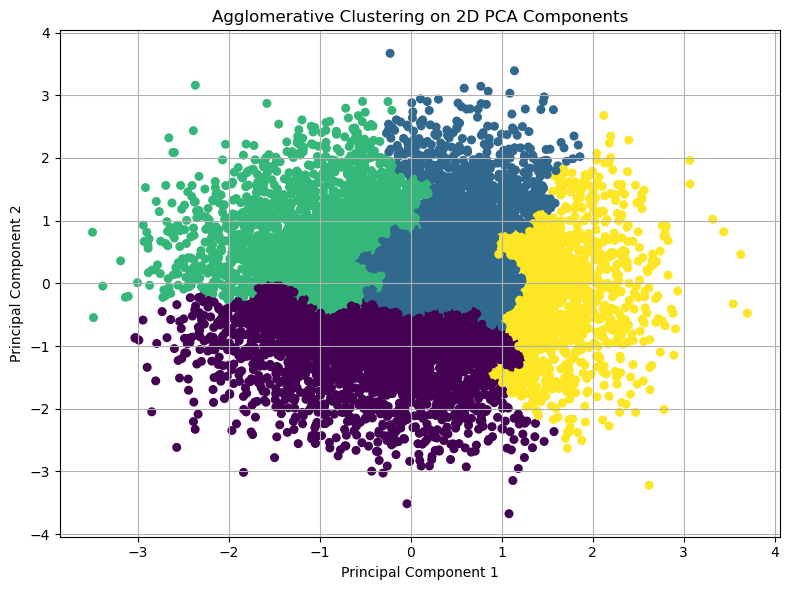

K-Means Clustering:
  Silhouette Score: 0.3307
  Calinski-Harabasz Score: 6047.3392
  Davies-Bouldin Score: 0.9370

DBSCAN Clustering:
  Silhouette Score: 0.5157
  Calinski-Harabasz Score: 16.6568
  Davies-Bouldin Score: 2.6415

Agglomerative Clustering:
  Silhouette Score: 0.2684
  Calinski-Harabasz Score: 4763.8509
  Davies-Bouldin Score: 1.0863


K-Means Cluster Centroids (in original feature space):
|    | Age     | Gender   | Blood Pressure   | Cholesterol Level   | Exercise Habits   | Smoking   | Family Heart Disease   | Diabetes   | BMI     | High Blood Pressure   | Low HDL Cholesterol   | High LDL Cholesterol   | Alcohol Consumption   | Stress Level   | Sleep Hours   | Sugar Consumption   | Triglyceride Level   | Fasting Blood Sugar   | CRP Level   | Homocysteine Level   |
|:---|:--------|:---------|:-----------------|:--------------------|:------------------|:----------|:-----------------------|:-----------|:--------|:----------------------|:----------------------|:-----------

In [5]:
# --- Optimal number of clusters (set manually or automate if needed) ---
k_optimal = 3  # <-- change based on Elbow result

# --- K-Means Clustering ---
pca_for_kmeans = df_pca[['PC1', 'PC2']].copy()
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_for_kmeans)
df_pca['kmeans_cluster'] = kmeans_labels

# --- DBSCAN Clustering ---
min_samples = 4
neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(df_pca[['PC1', 'PC2']])
distances, indices = nbrs.kneighbors(df_pca[['PC1', 'PC2']])
distances = np.sort(distances[:, min_samples - 1])

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel('Epsilon (Eps)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Set eps manually after inspecting graph
dbscan = DBSCAN(eps=0.5, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(df_pca[['PC1', 'PC2']])
df_pca['dbscan_cluster'] = dbscan_labels

# --- Agglomerative Clustering ---
k_optimal_agnes = 4  # <-- change based on your analysis
pca_for_agnes = df_pca[['PC1', 'PC2']].copy()
agnes = AgglomerativeClustering(n_clusters=k_optimal_agnes, linkage='ward')
agnes_labels = agnes.fit_predict(pca_for_agnes)
df_pca['agnes_cluster'] = agnes_labels

# --- Visualization ---
def plot_clusters(title, labels, filename):
    plt.figure(figsize=(8, 6))
    plt.scatter(df_pca['PC1'], df_pca['PC2'], c=labels, cmap='viridis', s=30)
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    #plt.savefig(filename)

plot_clusters('K-Means Clustering on 2D PCA Components', kmeans_labels, 'kmeans_2d_scatter.png')
plot_clusters('DBSCAN Clustering on 2D PCA Components', dbscan_labels, 'dbscan_2d_scatter.png')
plot_clusters('Agglomerative Clustering on 2D PCA Components', agnes_labels, 'agnes_2d_scatter.png')

# --- Evaluation Metrics ---
def evaluate_clustering(name, data, labels):
    # Only evaluate if more than 1 cluster and no all-noise
    if len(set(labels)) > 1 and len(set(labels)) != 1 and (set(labels) != {-1}):
        silhouette = silhouette_score(data, labels)
        ch_score = calinski_harabasz_score(data, labels)
        db_score = davies_bouldin_score(data, labels)
        print(f"{name} Clustering:")
        print(f"  Silhouette Score: {silhouette:.4f}")
        print(f"  Calinski-Harabasz Score: {ch_score:.4f}")
        print(f"  Davies-Bouldin Score: {db_score:.4f}\n")
    else:
        print(f"{name} Clustering: Not enough clusters to evaluate.\n")

evaluate_clustering("K-Means", pca_for_kmeans, kmeans_labels)
evaluate_clustering("DBSCAN", df_pca[['PC1', 'PC2']], dbscan_labels)
evaluate_clustering("Agglomerative", pca_for_agnes, agnes_labels)

# --- Derive Business Insights ---
# Analyze the cluster centroids.
# First, reverse the PCA transformation to get the original features for the centroids.
# Then, reverse the scaling to get the original values.
kmeans_centroids_pca = kmeans.cluster_centers_
kmeans_centroids_scaled = pca.inverse_transform(kmeans_centroids_pca)
kmeans_centroids_original = scaler.inverse_transform(kmeans_centroids_scaled)

# Create a DataFrame for the centroids.
centroids_df = pd.DataFrame(kmeans_centroids_original, columns=df_processed.columns)
print('\nK-Means Cluster Centroids (in original feature space):')
print(centroids_df.to_markdown(numalign="left", stralign="left"))

In [6]:
# Display all cluster centroids as a markdown table
print('\nK-Means Cluster Centroids (in original feature space):')
print(centroids_df.to_markdown(numalign="left", stralign="left"))

# Print all features for each cluster one by one
for i, row in centroids_df.iterrows():
    print(f"\nCluster {i} - Feature Profile:")
    for feature, value in row.items():
        print(f"  {feature}: {value:.2f}")



K-Means Cluster Centroids (in original feature space):
|    | Age     | Gender   | Blood Pressure   | Cholesterol Level   | Exercise Habits   | Smoking   | Family Heart Disease   | Diabetes   | BMI     | High Blood Pressure   | Low HDL Cholesterol   | High LDL Cholesterol   | Alcohol Consumption   | Stress Level   | Sleep Hours   | Sugar Consumption   | Triglyceride Level   | Fasting Blood Sugar   | CRP Level   | Homocysteine Level   |
|:---|:--------|:---------|:-----------------|:--------------------|:------------------|:----------|:-----------------------|:-----------|:--------|:----------------------|:----------------------|:-----------------------|:----------------------|:---------------|:--------------|:--------------------|:---------------------|:----------------------|:------------|:---------------------|
| 0  | 55.862  | 0.338167 | 147.297          | 235.3               | 0.977541          | 0.611529  | 0.468438               | 0.531069   | 30.4892 | 0.607967              | 0